In [167]:
import os, sys, re, pickle
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.utils.model_handling import get_models_evaluation_data, get_model_cfg
from src.utils.visualization import plot_training_metrics

In [168]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
plot_path = os.path.join(project_root, 'results', 'plots', 'baseline_vs_expert')

## Expert model

In [169]:
data_path = os.path.join(project_root, 'results', 'expert')
files = os.listdir(data_path)

expert_data = {}

for filename in files:
    sim_file_match = re.search(r"env_setup-(.*?)\.pkl$", filename)

    if sim_file_match:
        data_path = os.path.join(project_root, 'results', 'expert', filename)
        value = sim_file_match.group(1)

        coef_of_var_match = re.search(r"coef_of_var_(\d+)", value)
        if coef_of_var_match:
            coef_of_var = int(coef_of_var_match.group(1))

            with open(data_path, 'rb') as f:
                expert_eval_data = pickle.load(f)

            env_seeds = [int(re.findall(r'\d+', seed)[0]) for seed in list(expert_eval_data.keys())]
            acc_rewards = [int(np.sum(ep_rewards)) for ep_rewards in list(expert_eval_data.values())]

            expert_data[coef_of_var] = {'env_seed': env_seeds, 'acumulated_rewards': acc_rewards}

expert_data = dict(sorted(expert_data.items()))

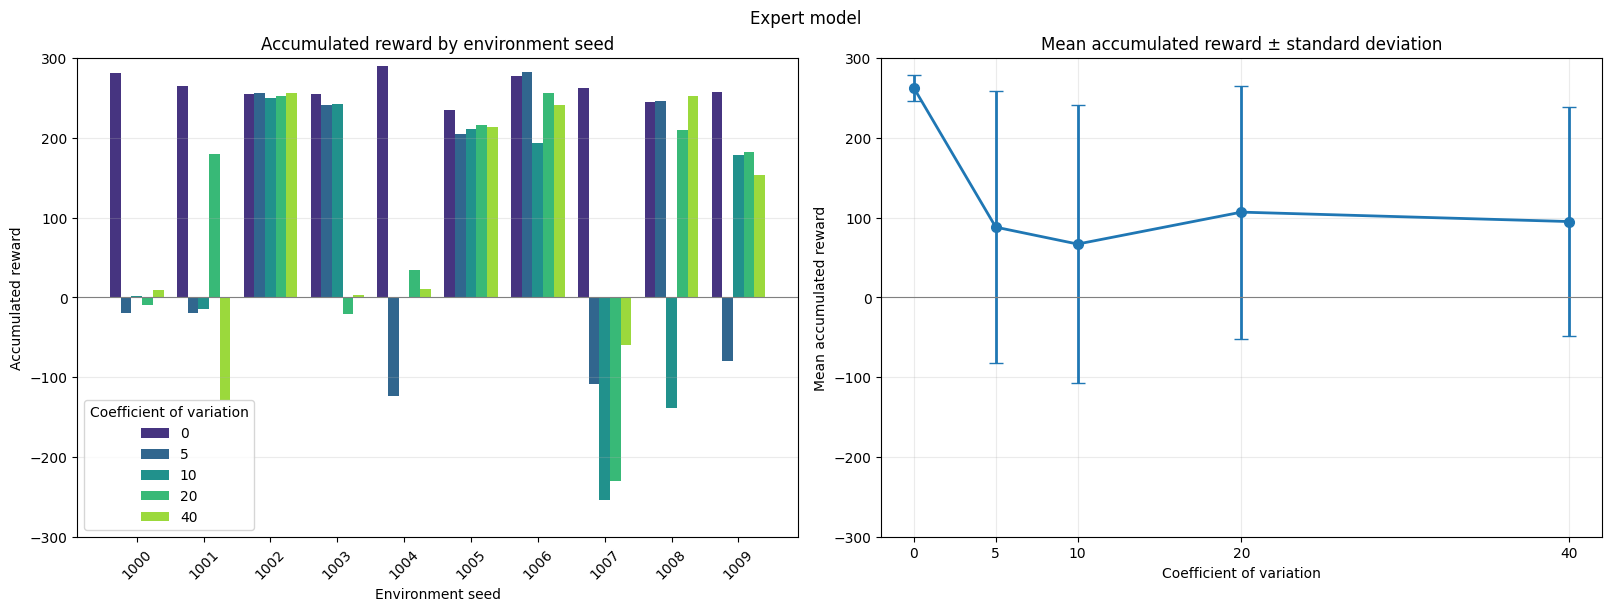

In [170]:
# Sort coefficient-of-variation levels numerically
coef_levels = sorted(expert_data.keys(), key=float)

# Assume each coefficient contains the same seeds
seeds = expert_data[coef_levels[0]]["env_seed"]

x = np.arange(len(seeds))
n_coefs = len(coef_levels)
group_width = 0.8
bar_width = group_width / n_coefs

colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_coefs))

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6),
    constrained_layout=True
)

# Plot 1: grouped rewards for every environment seed
for i, (coef, color) in enumerate(zip(coef_levels, colors)):
    data = expert_data[coef]

    # Associate every seed with its corresponding reward
    reward_by_seed = dict(
        zip(data["env_seed"], data["acumulated_rewards"])
    )

    rewards = [reward_by_seed.get(seed, np.nan) for seed in seeds]
    offset = (i - (n_coefs - 1) / 2) * bar_width

    ax1.bar(
        x + offset,
        rewards,
        width=bar_width,
        color=color,
        label=str(coef)
    )

ax1.set_xticks(x)
ax1.set_ylim(-300, 300)
ax1.set_xticklabels(seeds, rotation=45)
ax1.set_xlabel("Environment seed")
ax1.set_ylabel("Accumulated reward")
ax1.set_title("Accumulated reward by environment seed")
ax1.legend(title="Coefficient of variation")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.grid(axis="y", alpha=0.25)


# Plot 2: mean and standard deviation for each coefficient
means = []
stds = []

for coef in coef_levels:
    rewards = np.asarray(
        expert_data[coef]["acumulated_rewards"],
        dtype=float
    )

    means.append(rewards.mean())
    stds.append(rewards.std(ddof=1))

coef_values = np.asarray(coef_levels, dtype=float)

ax2.errorbar(
    coef_values,
    means,
    yerr=stds,
    fmt="o-",
    linewidth=2,
    markersize=7,
    capsize=5
)

ax2.set_xticks(coef_values)
ax2.set_ylim(-300, 300)
ax2.set_xticklabels(coef_levels)
ax2.set_xlabel("Coefficient of variation")
ax2.set_ylabel("Mean accumulated reward")
ax2.set_title("Mean accumulated reward ± standard deviation")
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.grid(alpha=0.25)
plt.suptitle('Expert model')

plt.show()

## Transformer model

In [171]:
def plot_transformer_data(model, seq_len):
    data_path = os.path.join(project_root, 'results', 'models', model)
    files = os.listdir(data_path)

    expert_data = {}

    for filename in files:
        sim_file_match = re.search(fr"evaluation-{seq_len}-{model}-reward_per_episode_all-env_setup-(.*?)\.pkl$", filename)

        if sim_file_match:
            data_path = os.path.join(project_root, 'results', 'models', model, filename)
            value = sim_file_match.group(1)

            coef_of_var_match = re.search(r"coef_of_var_(\d+)", value)
            if coef_of_var_match:
                coef_of_var = int(coef_of_var_match.group(1))

                with open(data_path, 'rb') as f:
                    expert_eval_data = pickle.load(f)

                env_seeds = [int(re.findall(r'\d+', seed)[0]) for seed in list(expert_eval_data.keys())]
                acc_rewards = [int(np.sum(ep_rewards)) for ep_rewards in list(expert_eval_data.values())]

                expert_data[coef_of_var] = {'env_seed': env_seeds, 'acumulated_rewards': acc_rewards}

    expert_data = dict(sorted(expert_data.items()))

    # Sort coefficient-of-variation levels numerically
    coef_levels = sorted(expert_data.keys(), key=float)

    # Assume each coefficient contains the same seeds
    seeds = expert_data[coef_levels[0]]["env_seed"]

    x = np.arange(len(seeds))
    n_coefs = len(coef_levels)
    group_width = 0.8
    bar_width = group_width / n_coefs

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_coefs))

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(16, 6),
        constrained_layout=True
    )

    # Plot 1: grouped rewards for every environment seed
    for i, (coef, color) in enumerate(zip(coef_levels, colors)):
        data = expert_data[coef]

        # Associate every seed with its corresponding reward
        reward_by_seed = dict(
            zip(data["env_seed"], data["acumulated_rewards"])
        )

        rewards = [reward_by_seed.get(seed, np.nan) for seed in seeds]
        offset = (i - (n_coefs - 1) / 2) * bar_width

        ax1.bar(
            x + offset,
            rewards,
            width=bar_width,
            color=color,
            label=str(coef)
        )

    ax1.set_xticks(x)
    ax1.set_ylim(-300, 300)
    ax1.set_xticklabels(seeds, rotation=45)
    ax1.set_xlabel("Environment seed")
    ax1.set_ylabel("Accumulated reward")
    ax1.set_title("Accumulated reward by environment seed")
    ax1.legend(title="Coefficient of variation")
    ax1.axhline(0, color="gray", linewidth=0.8)
    ax1.grid(axis="y", alpha=0.25)


    # Plot 2: mean and standard deviation for each coefficient
    means = []
    stds = []

    for coef in coef_levels:
        rewards = np.asarray(
            expert_data[coef]["acumulated_rewards"],
            dtype=float
        )

        means.append(rewards.mean())
        stds.append(rewards.std(ddof=1))

    coef_values = np.asarray(coef_levels, dtype=float)

    ax2.errorbar(
        coef_values,
        means,
        yerr=stds,
        fmt="o-",
        linewidth=2,
        markersize=7,
        capsize=5
    )

    ax2.set_xticks(coef_values)
    ax2.set_ylim(-300, 300)
    ax2.set_xticklabels(coef_levels)
    ax2.set_xlabel("Coefficient of variation")
    ax2.set_ylabel("Mean accumulated reward")
    ax2.set_title("Mean accumulated reward ± standard deviation")
    ax2.axhline(0, color="gray", linewidth=0.8)
    ax2.grid(alpha=0.25)
    plt.suptitle(f'Model {model}')

    plt.show()

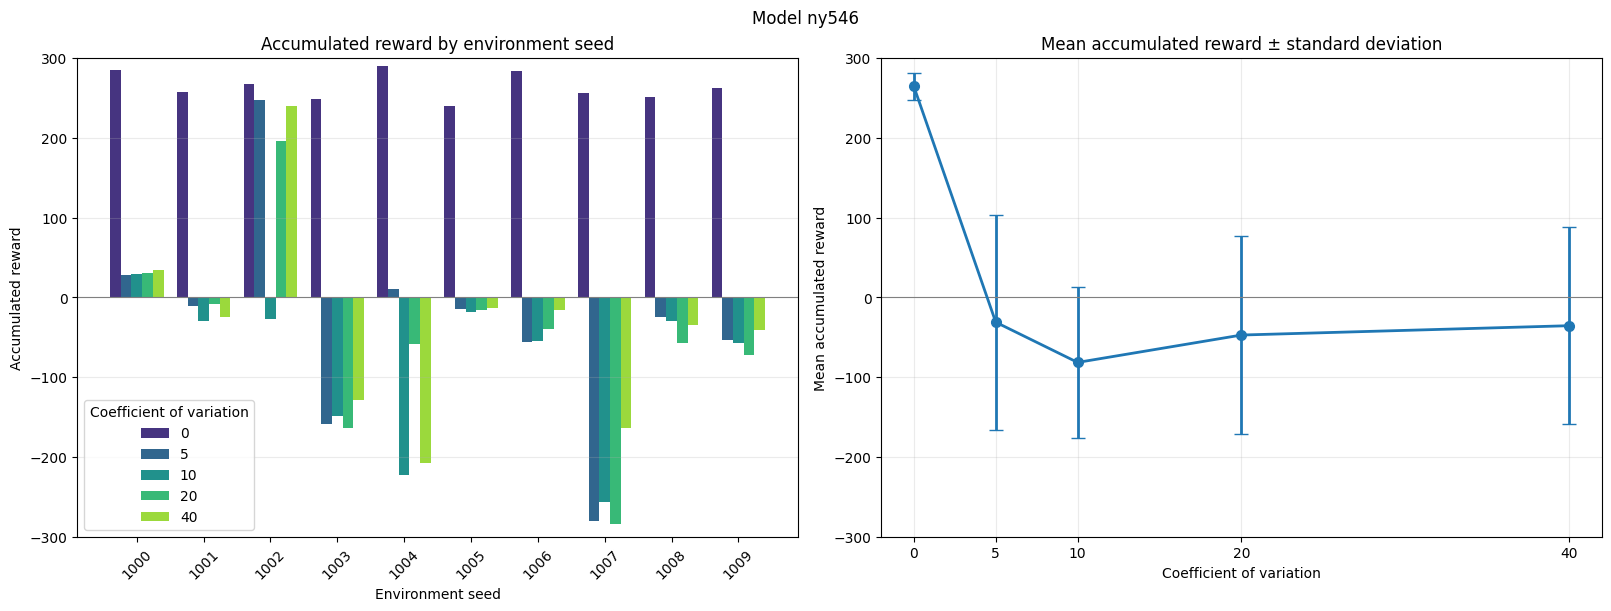

In [172]:
plot_transformer_data(model='ny546', seq_len=6)

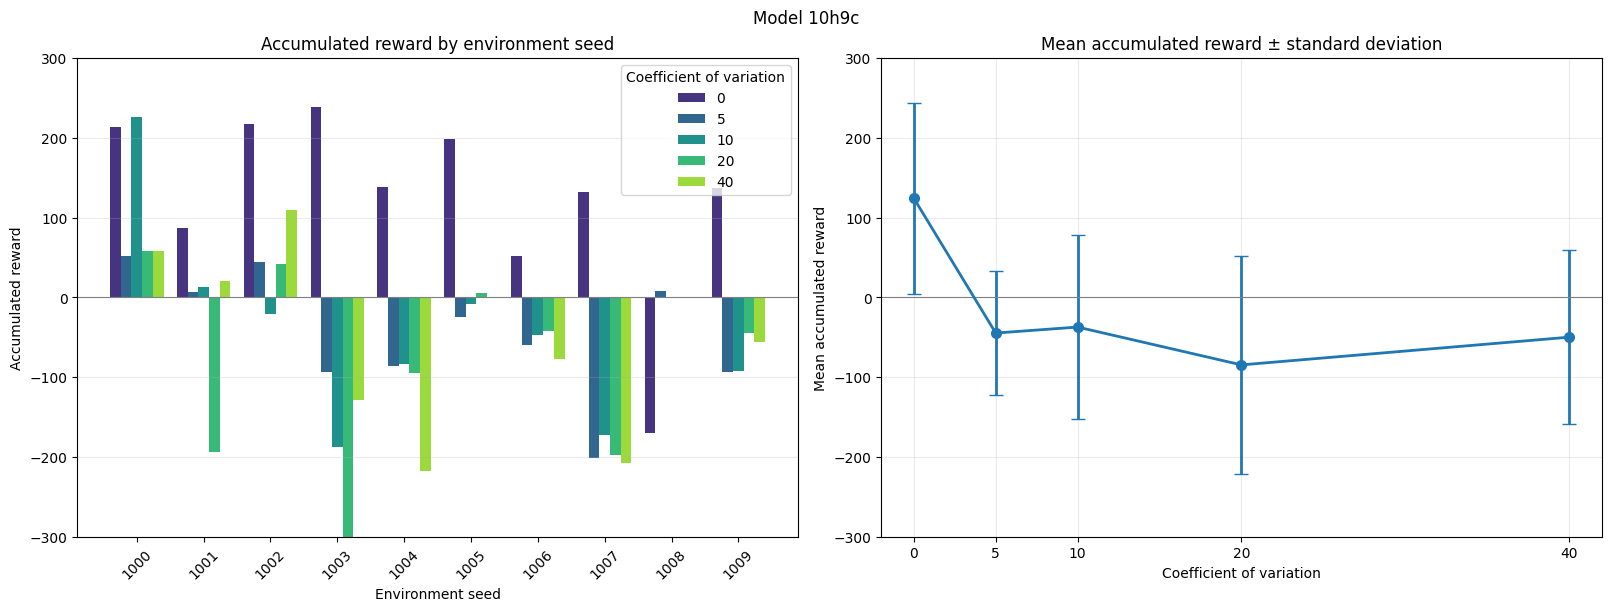

In [173]:
plot_transformer_data(model='10h9c', seq_len=10)